In [22]:
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np

In [ ]:
from google import genai
from google.genai import types
client = genai.Client(api_key="GEMINI API KEY")

In [3]:
response = client.models.generate_content(
    model="gemini-3.1-flash-lite",
    contents="You are an AI data analyst. Explain what a dataframe is in one sentence."
)

print(response.text)

A dataframe is a two-dimensional, tabular data structure that organizes information into labeled rows and columns, similar to a spreadsheet or a SQL table, to facilitate efficient data manipulation and analysis.


In [8]:
df= pd.read_csv('data.csv')
df.shape

(1000, 8)

In [9]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [10]:
import duckdb

con = duckdb.connect()

In [11]:
con.register("data", df)

In [14]:
result = con.execute("""
    SELECT *
    FROM data
    limit 5
""").fetchdf()

result

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [60]:
#Tools 1.0


def lookup_schema(conn, table_name):
    schema = conn.execute(f"DESCRIBE {table_name}").fetchdf()

    return schema


def run_sql(conn,query):
    query_lower = query.lower().strip()

    forbidden = [
        "drop",
        "delete",
        "update",
        "alter",
        "insert",
        "create"
    ]

    for word in forbidden:
        if word in query_lower:
            raise ValueError(f"Forbidden SQL operation: {word}")

    result = conn.execute(query).fetchdf()

    return result.head(100)






def make_chart(df, chart_type, x, y=None, title=None):
    """
    Create a chart from a pandas DataFrame.

    Parameters
    ----------
    df : pandas.DataFrame
        Data to visualize.

    chart_type : str
        Supported chart types:
        - bar
        - line
        - scatter
        - histogram
        - box

    x : str
        Column to use on the x-axis.

    y : str, optional
        Column to use on the y-axis.

    title : str, optional
        Chart title.

    Returns
    -------
    matplotlib.axes.Axes
        The generated chart.
    """

    supported_types = {
        "bar",
        "line",
        "scatter",
        "histogram",
        "box"
    }

    if chart_type not in supported_types:
        raise ValueError(
            f"Unsupported chart type: {chart_type}. "
            f"Supported types: {supported_types}"
        )

    if x not in df.columns:
        raise ValueError(f"Column '{x}' not found in dataframe.")

    if y is not None and y not in df.columns:
        raise ValueError(f"Column '{y}' not found in dataframe.")

    fig, ax = plt.subplots(figsize=(10, 6))

    if chart_type == "bar":
        ax.bar(df[x].astype(str), df[y])
        ax.set_xlabel(x)
        ax.set_ylabel(y)

    elif chart_type == "line":
        ax.plot(df[x], df[y], marker="o")
        ax.set_xlabel(x)
        ax.set_ylabel(y)

    elif chart_type == "scatter":
        ax.scatter(df[x], df[y])
        ax.set_xlabel(x)
        ax.set_ylabel(y)

    elif chart_type == "histogram":
        ax.hist(df[x].dropna(), bins=20)
        ax.set_xlabel(x)
        ax.set_ylabel("Frequency")

    elif chart_type == "box":
        ax.boxplot(df[x].dropna())
        ax.set_ylabel(x)

    if title:
        ax.set_title(title)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return ax

In [16]:
lookup_schema(con,'data')

,column_name,column_type,null,key,default,extra
0,gender,VARCHAR,YES,None,None,None
1,race_ethnicity,VARCHAR,YES,None,None,None
2,parental_level_of_education,VARCHAR,YES,None,None,None
3,lunch,VARCHAR,YES,None,None,None
4,test_preparation_course,VARCHAR,YES,None,None,None
5,math_score,BIGINT,YES,None,None,None
6,reading_score,BIGINT,YES,None,None,None
7,writing_score,BIGINT,YES,None,None,None


In [20]:
run_sql(con,'select * from data limit 2')

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


In [27]:
chart_tool = {
    "name": "make_chart",
    "description": """
    Create a chart from a pandas DataFrame.

    Use this tool when the user asks for a visualization,
    graph, plot, trend chart, comparison chart, or similar.

    Supported chart types:
    - bar
    - line
    - scatter
    - histogram
    - box
    """,
    "parameters": {
        "type": "object",
        "properties": {
            "chart_type": {
                "type": "string",
                "enum": [
                    "bar",
                    "line",
                    "scatter",
                    "histogram",
                    "box"
                ],
                "description": "The type of chart to create."
            },
            "x": {
                "type": "string",
                "description": "Column to use for the x-axis."
            },
            "y": {
                "type": "string",
                "description": "Column to use for the y-axis."
            },
            "title": {
                "type": "string",
                "description": "Title for the chart."
            }
        },
        "required": [
            "chart_type",
            "x",
            "y"
        ]
    }
}

In [29]:
response = client.models.generate_content(
    model="gemini-3.1-flash-lite",
    contents="""
    The user wants a visualization of the signup data.

    Available dataframe columns are:
    region
    signups

    Decide whether you should use the chart tool.
    """,
    config=types.GenerateContentConfig(
        tools=[
            types.Tool(
                function_declarations=[
                    types.FunctionDeclaration(
                        name="make_chart",
                        description=chart_tool["description"],
                        parameters=chart_tool["parameters"]
                    )
                ]
            )
        ]
    )
)

In [30]:
print(response)

sdk_http_response=HttpResponse(
  headers=<dict len=12>
) candidates=[Candidate(
  content=Content(
    parts=[
      Part(
        function_call=FunctionCall(
          args={
            'chart_type': 'bar',
            'title': 'Signups by Region',
            'x': 'region',
            'y': 'signups'
          },
          id='call_555289',
          name='make_chart'
        ),
        thought_signature=b"\x12q\no\x01\x11M2\x0fg\xfe\xd1q\xd2:a|\xc1\xde\tn=\x07u\x9d\x0c\xc5\xb5\x0f9\xe6Q\xcf[\x04:<\xb6M\x95n\xado\xb2|\x13\xcfP\x11\xd1\x880U\xfe\xba\xb0\xa2&\x9d\xe4\x8e|\xad\x1d\xda'\xca\x15\xcc\x9e.?Q7\xaa\\\xb4\xfb\x1f\x10+\xf1\xf4\xff\xfb\xfb<\x1b\xd9\xcd\xce\xc6[Iqk\xa8...'
      ),
    ],
    role='model'
  ),
  finish_reason=<FinishReason.STOP: 'STOP'>,
  index=0
)] create_time=None model_version='gemini-3.1-flash-lite' prompt_feedback=None response_id='HTWlar3ED8r1g8UP_b-a0Ag' usage_metadata=GenerateContentResponseUsageMetadata(
  candidates_token_count=40,
  prompt_token_cou

In [31]:
print(response.candidates[0].content.parts)

[Part(
  function_call=FunctionCall(
    args={
      'chart_type': 'bar',
      'title': 'Signups by Region',
      'x': 'region',
      'y': 'signups'
    },
    id='call_555289',
    name='make_chart'
  ),
  thought_signature=b"\x12q\no\x01\x11M2\x0fg\xfe\xd1q\xd2:a|\xc1\xde\tn=\x07u\x9d\x0c\xc5\xb5\x0f9\xe6Q\xcf[\x04:<\xb6M\x95n\xado\xb2|\x13\xcfP\x11\xd1\x880U\xfe\xba\xb0\xa2&\x9d\xe4\x8e|\xad\x1d\xda'\xca\x15\xcc\x9e.?Q7\xaa\\\xb4\xfb\x1f\x10+\xf1\xf4\xff\xfb\xfb<\x1b\xd9\xcd\xce\xc6[Iqk\xa8...'
)]


In [40]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [55]:
user_question = """
i want a line plot between math_score and writing_score.
"""

In [56]:
response = client.models.generate_content(
    model='gemini-3.1-flash-lite',
    contents=user_question,
    config=types.GenerateContentConfig(
        tools=[
            types.Tool(
                function_declarations=[
                    types.FunctionDeclaration(
                        name="make_chart",
                        description=chart_tool["description"],
                        parameters=chart_tool["parameters"]
                    )
                ]
            )
        ]
    )
)

In [57]:
print(response.candidates[0].content.parts)

[Part(
  function_call=FunctionCall(
    args={
      'chart_type': 'line',
      'title': 'Math Score vs Writing Score',
      'x': 'math_score',
      'y': 'writing_score'
    },
    id='call_1815930',
    name='make_chart'
  ),
  thought_signature=b'\x12q\no\x01\x11M2\x0fr\x8b\x9b\xfe\x00\x07\x06\xf9!\xd8\xf3N\xd20\x9c\x05}\x87\x8b\xc5\x8f\xb8q/\x86\x17\xd1\xa0L\x93\xc2\x98\xb9\xeba\xa2\xb5\x84Gs\xfd\xc8\xea\x02\xf7\x0e\xa1\xe3\xa7u\xe4\xf8S\x13\nj\xca\xd2\x92\xbc\x05\x1b\xd5\x84\x970z;\\\t\xfa\xf2F\x98\x05\xb6X\x1e\xd5\xcc\xe35Q\r\x04\xfcy\x96...'
)]


In [58]:
for part in response.candidates[0].content.parts:

    if part.function_call:

        function_call = part.function_call

        print("Gemini requested tool:")
        print(function_call.name)

        print("\nArguments:")
        print(function_call.args)

Gemini requested tool:
make_chart

Arguments:
{'chart_type': 'line', 'y': 'writing_score', 'title': 'Math Score vs Writing Score', 'x': 'math_score'}


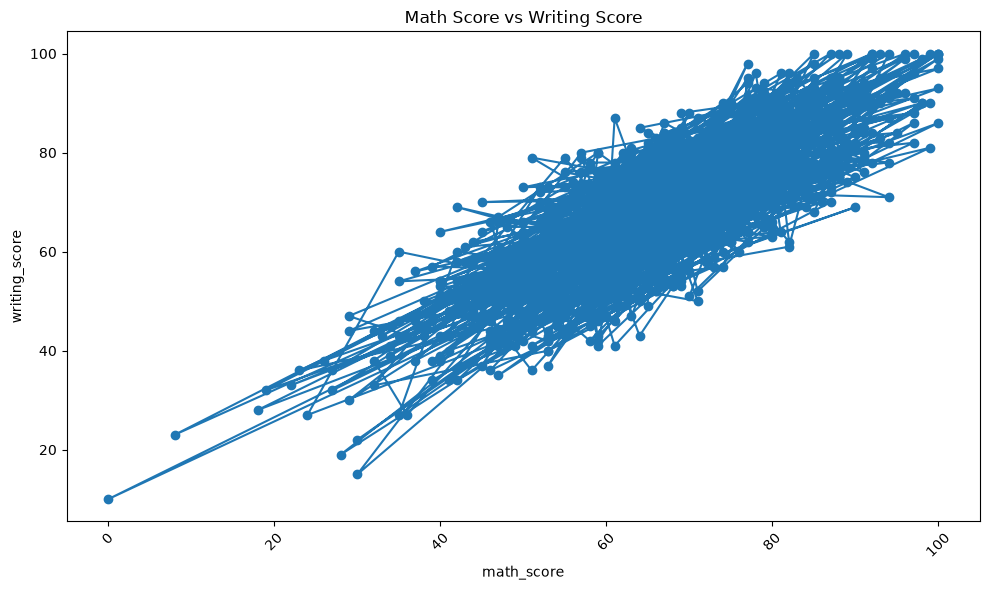

<Axes: title={'center': 'Math Score vs Writing Score'}, xlabel='math_score', ylabel='writing_score'>

In [59]:
args = function_call.args

make_chart(
    df=df,
    chart_type=args["chart_type"],
    x=args["x"],
    y=args["y"],
    title=args.get("title")
)